A Jupyter Notebook to grab quick and easy plots of the predictions based on the prostate MRI segmentation models.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from prostatemri_dataset import load_images, MRIDataset
from mriseg_models import SimpleUNet, TLDeepLabV3MobileNet
import utils

In [2]:
# Load validation dataset and create dataloader for plotting

val_images = load_images("val")

# Wrap the datasets and create dataloaders
val_dataset = MRIDataset(val_images)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [3]:
# Load the trained model

model = SimpleUNet()
model.load_state_dict(torch.load("prostate_unet.pth"))

# model = TLDeepLabV3MobileNet(backbone_unfreeze_substrings = ("5", "6"), classifier_unfreeze_last_K = 4)
# model.load_state_dict(torch.load("prostate_transfer_model.pth"))

<All keys matched successfully>

In [ ]:
def overlay_contours(ax, img_gray, gt_mask, pred_mask, gt_color='lime', pred_color='magenta', legend_flag=False):
    """ DRAWS OUTLINE OF THE GROUND TRUTH (GREEN) AND PREDICTED (MAGENTA) CONTOURS ON TOP OF THE GRAYSCALE IMAGE """
    
    # Display grayscale image as background
    ax.imshow(img_gray, cmap='gray', vmin=0, vmax=255)

    # Plot contours of the ground truth and predicted masks
    # Smoothing not needed; ensure masks are 0/1 floats for contouring at level=0.5
    gt_cs = ax.contour(gt_mask.astype(float), levels=[0.5], colors=gt_color, linewidths=2.0)
    pred_cs = ax.contour(pred_mask.astype(float), levels=[0.5], colors=pred_color, linewidths=2.0)

    if legend_flag:
        # Get legend handles from the contour sets
        gt_handles, _   = gt_cs.legend_elements()
        pred_handles, _ = pred_cs.legend_elements()

        # Specify handles and labels for the legend
        handles = [gt_handles[0], pred_handles[0]]
        labels  = ['Ground Truth', 'Predicted']

        # Add legend with line samples visible
        ax.legend(handles, labels, loc='upper left', frameon=True, fontsize=12)

    ax.set_axis_off()


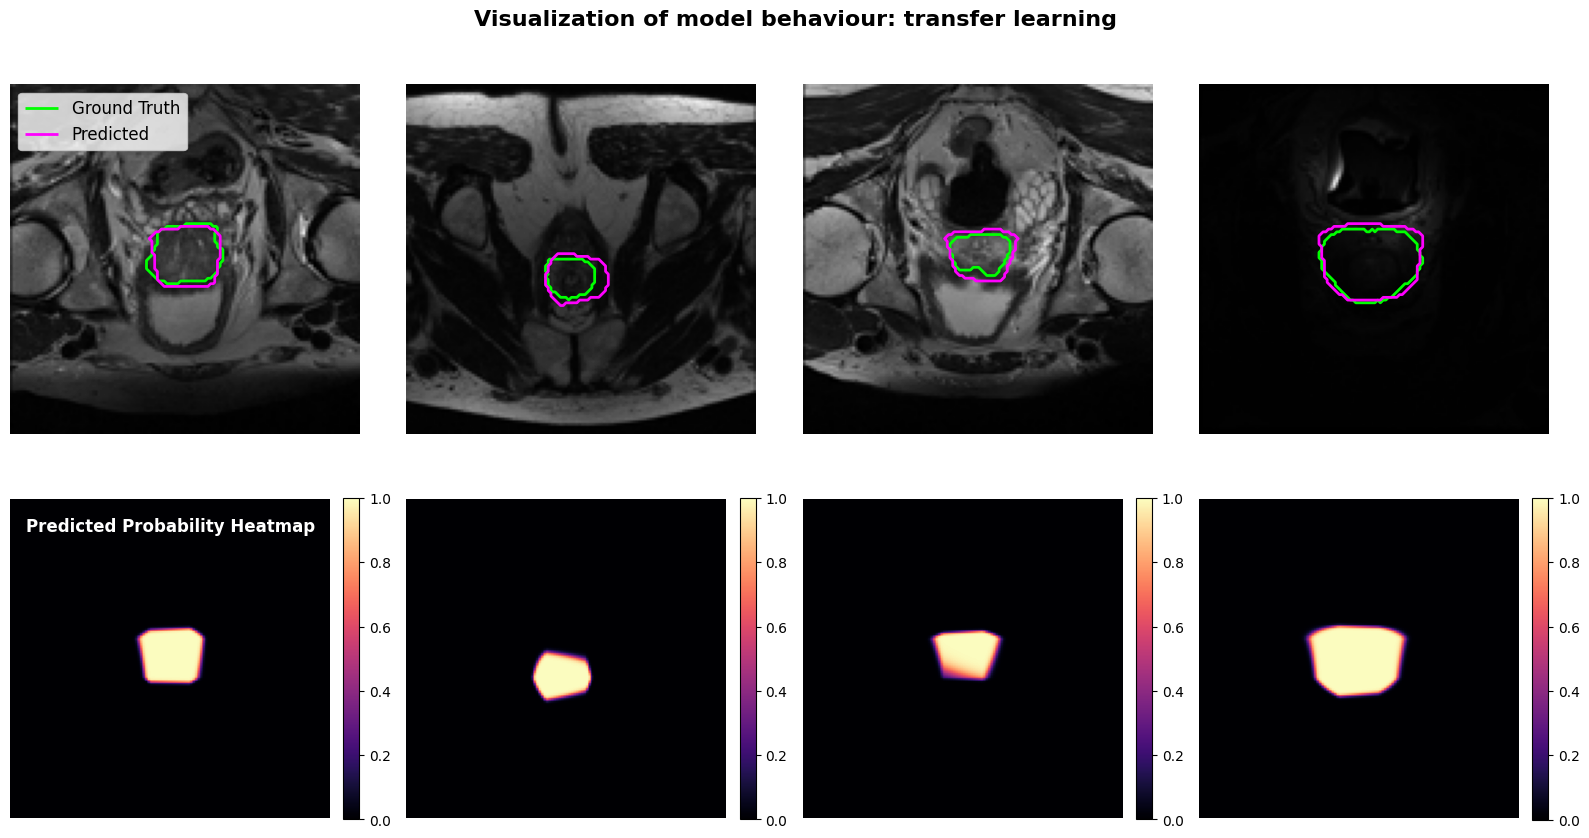

In [16]:
# Visualize predictions on validation set with contour overlays
num_samples = 4
fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 9))

model.eval()
with torch.no_grad():
    for idx in range(num_samples):
        images, _ = val_dataset[idx]              # images: (1,H,W) normalized
        image_batch = images.unsqueeze(0)         # (1,1,H,W)
        outputs = model(image_batch)

        # Handle dict or tensor output
        outputs = outputs['out'] if isinstance(outputs, dict) else outputs

        # Prob -> binary
        probs = torch.sigmoid(outputs).squeeze(0).squeeze(0).cpu().numpy()  # (H, W)
        predicted_mask = (probs > 0.5).astype(np.uint8)                      # (H, W)

        # Raw image + ground truth mask from base dataset
        raw_pil, mask_pil = val_dataset.base_dataset[idx]
        raw_np  = np.array(raw_pil.convert("L"))         # (H, W) uint8
        mask_np = (np.array(mask_pil) > 0).astype(np.uint8)

        # Ground truth vs predicted contours overlaid on raw image
        overlay_contours(axes[0, idx], raw_np, mask_np, predicted_mask, legend_flag=(idx==0))

        # Probability heatmap
        im = axes[1, idx].imshow(probs, cmap='magma', vmin=0, vmax=1)
        axes[1, idx].axis('off')
        fig.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)
        if idx == 0:
            axes[1, idx].text(0.05 , 0.9, 'Predicted Probability Heatmap', transform=axes[1, idx].transAxes, fontsize=12, color='white', weight='bold')

plt.suptitle("Visualization of model behaviour: transfer learning", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

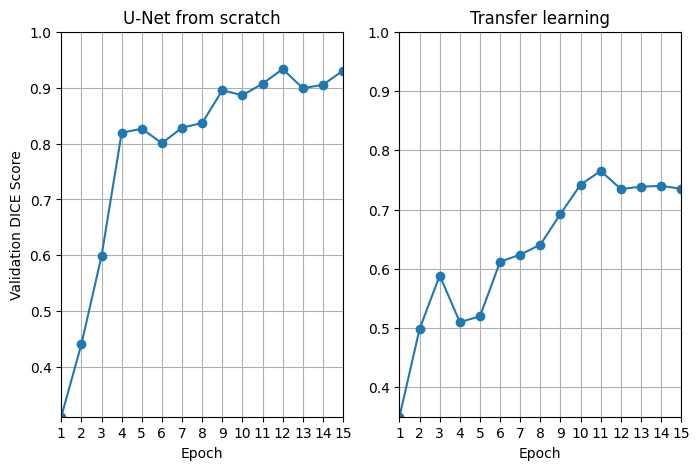

In [7]:
# Plot the validation DICE score across epochs during training

DICE_scores_scratch = np.load("DICE_scores/scratch_val_DICE_vs_epoch.npy")
epochs_scratch = np.arange(1, len(DICE_scores_scratch) + 1)
DICE_scores_tl = np.load("DICE_scores/transfer_val_DICE_vs_epoch.npy")
epochs_tl = np.arange(1, len(DICE_scores_tl) + 1)

fig, ax = plt.subplots(1, 2, figsize=(8,5))
ax[0].plot(epochs_scratch, DICE_scores_scratch, marker='o')
ax[0].set_xlim([1, len(epochs_scratch)])
ax[0].set_ylim([min(DICE_scores_scratch), 1])
ax[0].set_xticks(epochs_scratch)  # Set x-ticks to be integer epochs
ax[0].set_title("U-Net from scratch")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Validation DICE Score")
ax[0].grid()

ax[1].plot(epochs_tl, DICE_scores_tl, marker='o')
ax[1].set_xlim([1, len(epochs_tl)])
ax[1].set_ylim([min(DICE_scores_tl), 1])
ax[1].set_xticks(epochs_tl)  # Set x-ticks to be integer epochs
ax[1].set_title("Transfer learning")
ax[1].set_xlabel("Epoch")
# ax[1].set_ylabel("Validation DICE Score")
ax[1].grid()

plt.show()

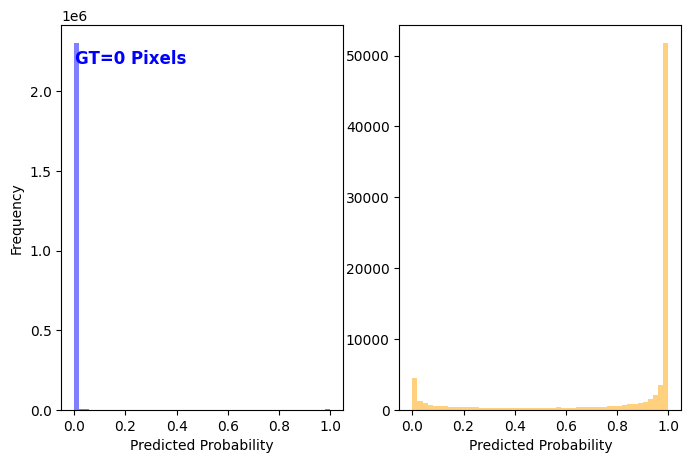

In [ ]:
# Plot a histogram of all probabilities across all pixels in the validation set, showing pixels where the ground truth is 1 and 0 separately

all_probs_gt1 = []
all_probs_gt0 = []
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        outputs = model(images)
        outputs = outputs['out'] if isinstance(outputs, dict) else outputs
        probs = torch.sigmoid(outputs).squeeze(1).cpu().numpy()  # (N, H, W)
        masks_np = masks.squeeze(1).cpu().numpy()                 # (N, H, W)

        all_probs_gt1.extend(probs[masks_np == 1].flatten())
        all_probs_gt0.extend(probs[masks_np == 0].flatten())


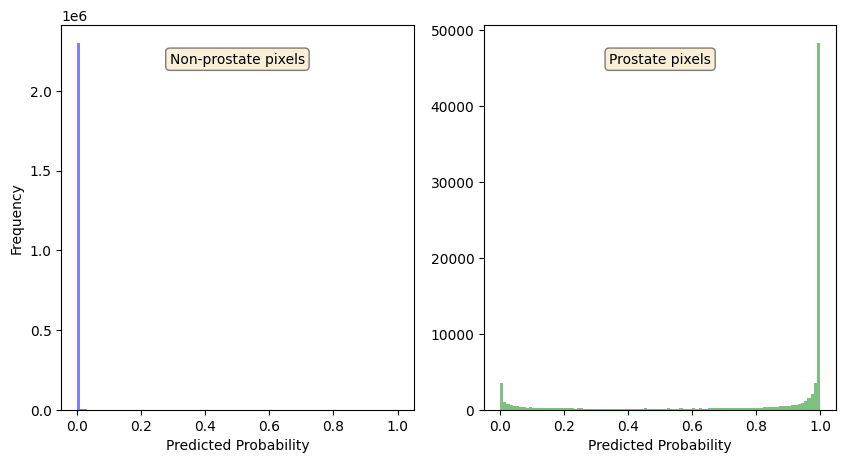

In [25]:
boxprops = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].hist(all_probs_gt0, bins=100, alpha=0.5, color='blue')
ax[0].set_xlabel("Predicted Probability")
ax[0].set_ylabel("Frequency")
ax[0].text(0.5 , 0.9, 'Non-prostate pixels', transform=ax[0].transAxes, horizontalalignment='center', fontsize=10, bbox=boxprops)

ax[1].hist(all_probs_gt1, bins=100, alpha=0.5, color='green')
ax[1].set_xlabel("Predicted Probability")
ax[1].text(0.5, 0.9, 'Prostate pixels', transform=ax[1].transAxes, horizontalalignment='center', fontsize=10, bbox=boxprops)
plt.show()

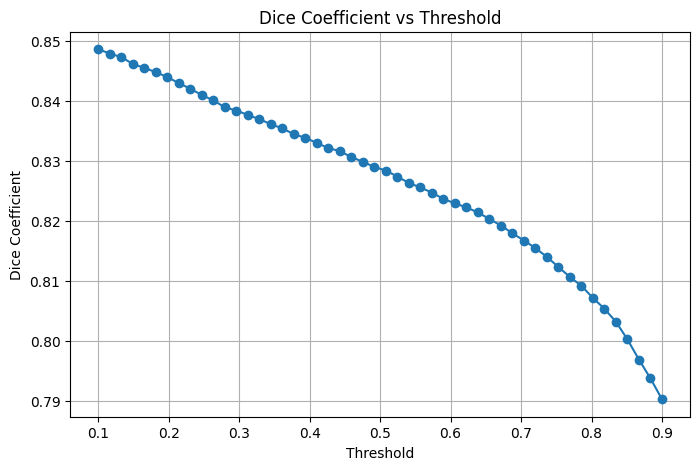

In [4]:
# Dice vs threshold curve for the validation set

thresholds = np.linspace(0.1, 0.9, 50)

dice_scores = []
model.eval()
with torch.no_grad():
    for threshold in thresholds:
        all_dice = []
        for images, masks in val_loader:
            outputs = model(images)
            outputs = outputs['out'] if isinstance(outputs, dict) else outputs # Depending on whether we are using the scratch UNet or transfer learning model
            masks_np = masks.squeeze(1).cpu().numpy()
            dice = utils.dice_coefficient(outputs, masks, threshold=threshold).item()
            all_dice.append(dice)
        dice_scores.append(np.mean(all_dice))
    
plt.figure(figsize=(8, 5))
plt.plot(thresholds, dice_scores, marker='o')
plt.title('Dice Coefficient vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Dice Coefficient')
plt.grid()
plt.show()
                            

In [7]:
# Create a Bland-Altman plot for the predicted vs ground truth areas across the validation set
all_gt_areas = []
all_pred_areas = []

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        outputs = model(images)
        outputs = outputs['out'] if isinstance(outputs, dict) else outputs # Depending on whether we are using the scratch UNet or transfer learning model
        masks_np = masks.squeeze(1).cpu().numpy()
        
        ba_batch = utils.bland_altman_areas(outputs, masks) # Function that calculates Bland-Altman areas for a given batch

        # Collect areas; ignore batch-level stats (compute once globally at end)
        all_gt_areas.append(ba_batch[0])
        all_pred_areas.append(ba_batch[1])

    # Concatenate across all batches
    gt_areas   = np.concatenate(all_gt_areas, axis=0)
    pred_areas = np.concatenate(all_pred_areas, axis=0)


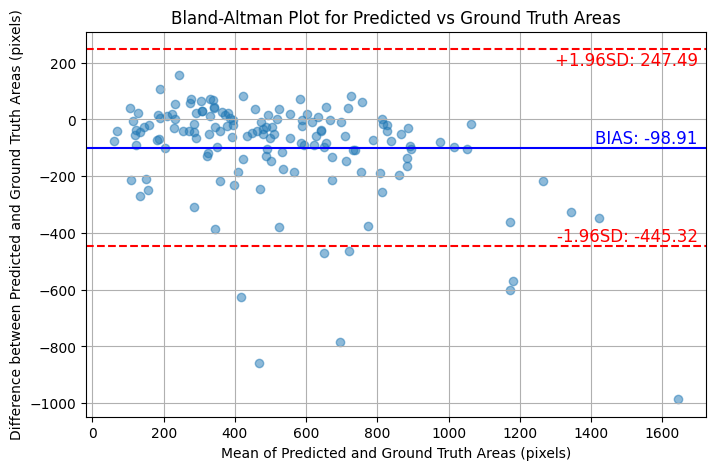

In [30]:
# Global Bland-Altman stats
means = 0.5 * (pred_areas + gt_areas)
diffs = pred_areas - gt_areas
bias = float(diffs.mean())
sd   = float(diffs.std(ddof=1)) if diffs.size > 1 else 0.0
loa_low  = bias - 1.96 * sd
loa_high = bias + 1.96 * sd

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(means, diffs, alpha=0.5)
ax.axhline(bias, color='blue', linestyle='-', label=f'Bias = {bias:.2f}')
ax.text(1700, bias, f'BIAS: {bias:.2f}', color='blue', fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.axhline(loa_low, color='red', linestyle='--', label=f'Lower LoA = {loa_low:.2f}')
ax.text(1700, loa_low, f'-1.96SD: {loa_low:.2f}', color='red', fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.axhline(loa_high, color='red', linestyle='--', label=f'Upper LoA = {loa_high:.2f}')
ax.text(1700, loa_high-8, f'+1.96SD: {loa_high:.2f}', color='red', fontsize=12, verticalalignment='top', horizontalalignment='right')
ax.set_xlabel('Mean of Predicted and Ground Truth Areas (pixels)')
ax.set_ylabel('Difference between Predicted and Ground Truth Areas (pixels)')
ax.set_title('Bland-Altman Plot for Predicted vs Ground Truth Areas')
plt.grid()
plt.show()